In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from minigrid.core.world_object import Ball, Goal, Wall
from utils.env import make_env
import matplotlib.pyplot as plt
from minigrid.core.constants import OBJECT_TO_IDX, COLOR_TO_IDX
from minigrid.core.grid import Grid
from model import ACModel

C:\Users\vikas\OneDrive\Desktop\CSE_PROJ\minigrid_static_fullobs\minigrid-static-fullobs\venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
# Constants
COLLISION_ID = 16
BALL_ID = OBJECT_TO_IDX['ball']
AGENT_ID = OBJECT_TO_IDX['agent']
EMPTY_ID = OBJECT_TO_IDX['empty']

def render_collision_numpy(grid_numpy):
    """
    Renders a (W, H, 3) numpy array containing custom ID 16.
    """
    # # --- 0. FIX: Convert PyTorch Tensor to Numpy ---
    # if hasattr(grid_input, 'cpu'):
    #     # detach() removes it from the gradient graph
    #     # cpu() moves it to CPU memory
    #     # numpy() converts it to a numpy array
    #     grid_numpy = grid_input.detach().cpu().numpy()
    # else:
    #     grid_numpy = grid_input
        
    # 1. Sanity Check: Ensure shape is (W, H, 3)
    # If it has a batch dimension (1, W, H, 3), remove it.
    if grid_numpy.ndim == 4:
        grid_numpy = grid_numpy[0]
        
    # 2. Create a copy to modify (don't mess up the original data)
    render_data = grid_numpy.copy()
    
    width, height, _ = render_data.shape
    agent_pos = None
    agent_dir = 0
    
    # 3. Scan the grid to find the Agent (ID 10) or Collision (ID 16)
    for i in range(width):
        for j in range(height):
            obj_id = render_data[i, j, 0]
            
            # --- CASE A: Collision (Agent on Ball) ---
            if obj_id == COLLISION_ID:
                # 1. Replace '16' with 'Ball' so Grid.decode() works
                render_data[i, j, 0] = BALL_ID 
                
                # 2. Extract Agent details
                agent_pos = (i, j)
                agent_dir = render_data[i, j, 2] # Direction is channel 2

            # --- CASE B: Normal Agent (Agent on Floor) ---
            elif obj_id == AGENT_ID:
                # 1. Replace '10' with 'Empty' so Grid.decode() works
                # (Standard MiniGrid maps don't include the agent in the grid definition)
                render_data[i, j, 0] = EMPTY_ID
                
                # 2. Extract Agent details
                agent_pos = (i, j)
                agent_dir = render_data[i, j, 2]

    # 4. Decode the "Cleaned" grid
    # Now render_data only contains standard IDs (Ball, Empty, Wall)
    try:
        grid = Grid.decode(render_data)
        grid = grid[0]
    except Exception as e:
        print(f"Error decoding grid: {e}")
        return

    # 5. Render
    if agent_pos is not None:
        # Draw the map + put the agent on top
        image = grid.render(
            tile_size=32,
            agent_pos=agent_pos,
            agent_dir=int(agent_dir)
        )
    else:
        # Just draw the map (Agent not found)
        image = grid.render(tile_size=32)

    # 6. Show Image
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"State Render (Agent at {agent_pos})")
    plt.show()

# --- USAGE ---
# my_numpy_grid = get_state_tensor_with_collision(env, ...)
# render_collision_numpy(my_numpy_grid)

def BATCHTENSOR_visualize_state(env, state_tensor, title="State Render"):
    """
    Visualizes a raw (8, 8, 3) tensor by loading it into the env.
    """
    # 1. Load the tensor state into the actual Env
    # (This uses the method you just added to the wrapper)
    env.env.load_state_from_tensor(state_tensor)
    
    # 2. Render using the standard MiniGrid renderer
    # Since your render_mode='rgb_array', this returns the image array
    img = env.render()
    
    # 3. Display
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [3]:
class ObsBatch:
    def __init__(self, tensor):
        self.image = tensor
def get_next_states_via_env(env, batch_tensor, policy):
    """
    1. Loads each state from batch_tensor into the Env.
    2. Gets Policy Action.
    3. Steps the Env.
    4. Returns the batch of Next States.
    """
    device = batch_tensor.device
    next_states_list = []
    
    # Iterate over every state in the batch
    for i in range(len(batch_tensor)):
        current_state = batch_tensor[i]
        
        # --- A. Load State ---
        try:
            env.load_state_from_tensor(current_state)
        except ValueError:
            # Fallback: If state is weird/empty, just keep it as is (identity)
            next_states_list.append(current_state)
            continue

        # --- B. Get Action from Policy ---
        # 1. Wrap state for Policy
        obs_input = ObsBatch(current_state.unsqueeze(0)) # Add batch dim (1, 8, 8, 3)
        
        # 2. Query Policy
        with torch.no_grad():
            dist, _, _ = policy(obs_input,None)
            action = dist.probs.argmax(dim=1).item() # Deterministic Action
        
        # --- C. Step the Environment ---
        # The env automatically handles physics and returns the new Tensor (wrapped in Dict)
        obs, reward, done, _, _ = env.step(action)
        
        # Extract the tensor from the dictionary {'image': tensor}
        next_tensor_numpy = obs['image'] 
        
        # Convert to Tensor
        next_tensor = torch.tensor(next_tensor_numpy, dtype=torch.float32, device=device)
        next_states_list.append(next_tensor)

    # --- D. Stack into Batch ---
    batch_next_states = torch.stack(next_states_list)
    
    return batch_next_states

In [6]:

def generate_transitions(ENV_NAME,num):
    """
    Generates all valid transitions using FULL OBSERVABILITY (8x8).
    Resulting states will be (N, 8, 8, 3).
    """
    print("Generating State Space (Full 8x8 Grid)...")
    
    states = []
    next_states_map = [] 
    
    # Masks lists
    is_goal = []
    is_unsafe = []
    is_start = []
    images=[]
    agentPos=[]
    direc=[]
    ob=[]
    # Access the base environment to manipulate the grid
    env = make_env(ENV_NAME,seed=1)
    base_env = env.unwrapped
    width = base_env.grid.width
    height = base_env.grid.height
    
    # Iterate over every cell and direction
    for seeds in range(num):
        env = make_env(ENV_NAME,seed=1)
        base_env = env.unwrapped
        for i in range(width):
            for j in range(height):
                cell = base_env.grid.get(i, j)
                
                # Skip Walls
                if cell is not None and isinstance(cell, Wall):
                    continue
        
                for direction in range(4):
                    # 1. Force Agent State
                    obs=env.get_temp_state(i,j,direction)
                    # base_env.agent_pos = (i, j)
                    # base_env.agent_dir = direction
                    agentPos.append((i,j))
                    direc.append(direction)
                    # --- THE FIX: Get Full 8x8 Observation ---
                    # grid.encode() returns the full (W, H, 3) array.
                    # It includes walls, objects, and the agent's position/dir.
                    # This matches what FullyObsWrapper provides.
                    ob.append(obs)
                    # img = base_env.render()
                    # images.append(img)
                    # Display using matplotlib
                    # plt.imshow(img)
                    # plt.axis('off') # Hide axes for a cleaner look
                    # plt.show()
                    # full_grid_image = base_env.grid.encode()
                    
                    # Ensure it matches the range [0, 255] or [0, 10] depending on normalization
                    # MiniGrid usually returns integers. We stick to that.
                    # states.append(full_grid_image)
                    
                    # Identify State Type
                    if cell is not None and isinstance(cell, Goal):
                        is_goal.append(True)
                        is_unsafe.append(False)
                        is_start.append(False)
                    elif cell is not None and isinstance(cell, Ball):
                        is_goal.append(False)
                        is_unsafe.append(True)
                        is_start.append(False)
                    elif i == 1 and j == 1 and direction==0: # Standard Start
                        is_goal.append(False)
                        is_unsafe.append(False)
                        is_start.append(True)
                    else:
                        is_goal.append(False)
                        is_unsafe.append(False)
                        is_start.append(False)

        is_goal=is_goal[:-2]
        is_unsafe=is_unsafe[:-2]
        is_start=is_start[:-2]
        agentPos=agentPos[:-2]
        direc=direc[:-2]
        ob=ob[:-2]
                    
                    # --- 2. Simulate Next States (Actions 0, 1, 2) ---
                    # current_transitions = []
                    # for action in [0, 1, 2]: # Left, Right, Forward
                    #     # Reset state for simulation
                    #     base_env.agent_pos = (i, j)
                    #     base_env.agent_dir = direction
                        
                    #     # Step the environment
                    #     # We ignore the returned 'obs' because it might be wrapped/partial.
                    #     # Instead, we look at the grid again after the step.
                    #     _ = env.step(action)
                        
                    #     # Get the Full 8x8 Grid for the NEXT state
                    #     next_full_image = base_env.grid.encode()
                    #     current_transitions.append(next_full_image)
                    
                    # next_states_map.append(current_transitions)
    
    
    print("_____-----____")
    idx=34
    # print(is_start)
    # plt.imshow(images[0])
    # plt.axis('off') # Hide axes for a cleaner look
    # plt.show()
    
    
    # Convert to Tensors
    # states shape: (N, 8, 8, 3)
    # states_tensor = torch.tensor(np.array(states), dtype=torch.float)
    # # next_states shape: (N, 3, 8, 8, 3)
    # next_states_tensor = torch.tensor(np.array(next_states_map), dtype=torch.float)
    
    
    masks = {
        "goal": torch.tensor(is_goal, dtype=torch.bool),
        "unsafe": torch.tensor(is_unsafe, dtype=torch.bool),
        "start": torch.tensor(is_start, dtype=torch.bool),
        "safe": ~torch.tensor(is_goal, dtype=torch.bool) & ~torch.tensor(is_unsafe, dtype=torch.bool)
    }
    
    # images_array = np.stack(ob)
    # images_tensor = torch.from_numpy(images_array).float()
    # input_tensor = images_tensor.permute(0, 3, 1, 2)
    # # print(input_tensor[0][2])
    # input_tensor/=255.0
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_numpy = np.stack(ob)
    batch_tensor = torch.tensor(batch_numpy, dtype=torch.float32, device=device)
    # batch_tensor=batch_tensor/16.0
    # print(batch_tensor)
    
    # var_check=ob[4][1]
    # print(type(var_check)
    # ,len(var_check))
    # print(var_check)
    idx=0
    # grid = Grid.decode(ob[idx])
    # grid=grid[0]
    # image = grid.render(tile_size=32, agent_pos=agentPos[idx],agent_dir=direc[idx])
    # plt.imshow(ob[141])
    # plt.axis('off')
    # plt.show()

#### CHECK IF BATCH_TENSOR IS BEING SAMPLED RIGHT BY PRINTING THE STATE (BATCH_TENSOR SAMPLED) ## 
    # device = batch_tensor.device
    # C_init = batch_tensor[masks["start"].to(device)]
    # C_unsafe = batch_tensor[masks["unsafe"].to(device)]
    # C_decrease = batch_tensor[masks["safe"].to(device) & ~masks["unsafe"].to(device)]
    # print(f"Total States: {len(batch_tensor)}")
    # # print(f"C_init:     {len(C_init)}")
    # # print(f"C_unsafe:   {len(C_unsafe)}")
    # # print(f"C_decrease: {len(C_decrease)}")
    # ratio=0.5
    # n_decrease = int(len(C_decrease) * ratio)
    # idx_decrease = torch.randperm(len(C_decrease))[:n_decrease]
    # t_decrease = C_decrease[idx_decrease]
    # # render_collision_numpy(t_decrease[0])
    # print(len(t_decrease))
    # BATCHTENSOR_visualize_state(env, t_decrease[5], title=" State")
    
    ####################
    # dummy_obs_space = {"image": (8,8,3)}
    # MODEL_PATH = "storage/modifiedreward/status.pt"
    # policy = ACModel(dummy_obs_space, env.action_space)
    # checkpoint = torch.load(MODEL_PATH)
    # if "model_state" in checkpoint:
    #     policy.load_state_dict(checkpoint["model_state"])
    # else:
    #     policy.load_state_dict(checkpoint)
    # next_states=get_next_states_via_env(env, C_decrease, policy)
    # print(next_states[2])
    # visualize_state(env, next_states[3], title="Next State")

    #####################

   
    ####------------tensor-render-func---###
    # render_collision_numpy(ob[124])
        
    # print(masks["start"])
    ## --------------tensor to image check ----------------- ## 
    # img_tensor = input_tensor[4]
    # img_to_plot = img_tensor.permute(1, 2, 0)
    # img_to_plot = img_to_plot * 255.0
    # img_final = img_to_plot.detach().cpu().numpy().astype('uint8')
    # print(img_final.shape)
    # plt.imshow(img_final)
    # plt.axis('off')
    # plt.show()
    #########_______________________________________#####
    
    # print(f"Generated {len(states)} fully observable states.")
    # print(f"Shape check: {batch_tensor.shape} (Should be N, 8, 8, 3)")
    return batch_tensor,masks,agentPos,direc

In [12]:
# ENV_NAME = "MiniGrid-Dynamic-Obstacles-16x16-v0"

# # # base_env = env.unwrapped
# # # img = base_env.render()
# # # img_final = img
# # # plt.imshow(img_final)
# # # plt.axis('off')
# # # plt.show()
# states,masks,_,_=generate_transitions(ENV_NAME,1)
# C_unsafe = states[masks["unsafe"].to('cpu')]
# print(C_unsafe.shape)

Generating State Space (Full 8x8 Grid)...
DYNAMIC OBSTACLES REACHED--------------------------------------00
DYNAMIC OBSTACLES REACHED--------------------------------------00
_____-----____
Shape check: torch.Size([782, 16, 16, 3]) (Should be N, 8, 8, 3)
torch.Size([32, 16, 16, 3])


Generating State Space (Full 8x8 Grid)...
_____-----____
Generated 144 fully observable states.
Shape check: torch.Size([144, 8, 8, 3]) (Should be N, 8, 8, 3)


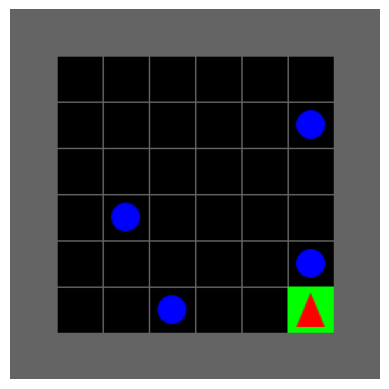

In [68]:

# _,_,_,st=generate_transitions(env)
# rgb_image = env.unwrapped.get_full_render(st.all(),tile_size=32)
# plt.imshow(rgb_image)
# plt.axis('off')
# plt.show()